In [16]:
# importaciones y Configuración Inicial
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import nltk
from nltk.corpus import treebank

# descargar corpus y tagset de NLTK para la sección 4
nltk.download('treebank', quiet=True)
nltk.download('universal_tagset', quiet=True)

# fijar semilla para garantizar la reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"PyTorch Version: {torch.__version__}")
print("Configuración completada y semilla fijada en 42.")


PyTorch Version: 2.14.1+cpu
Configuración completada y semilla fijada en 42.


[XOR Con ReLU] Pérdida final: 0.0001 | Exactitud: 100.0%
[XOR Sin Activación] Pérdida final: 0.6931 | Exactitud: 50.0%


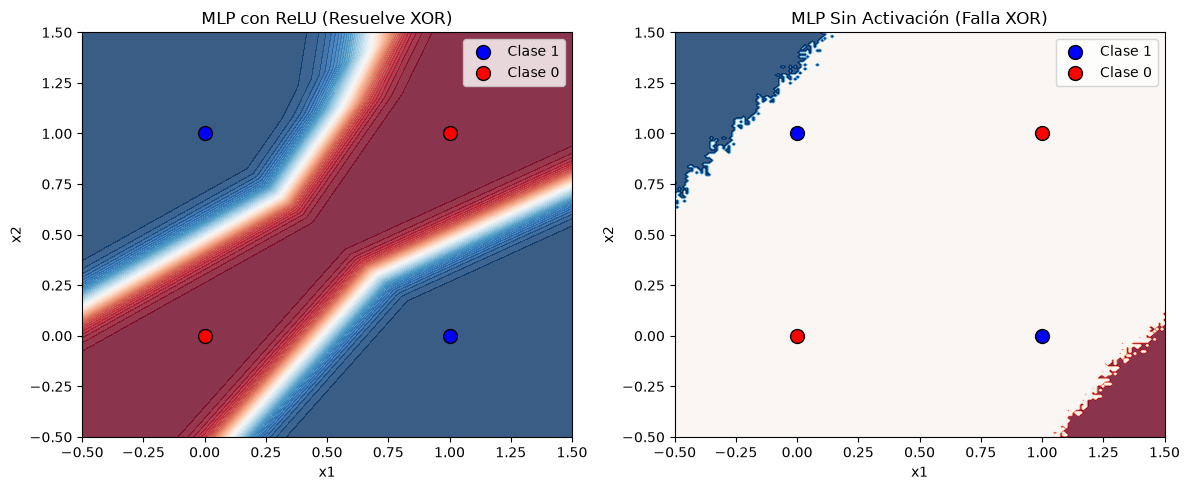


--- Parámetros del Modelo de la Diapositiva (3 -> 4 -> 4 -> 2) ---
Capa / Parámetro: fc1.weight   | Forma (Shape): [4, 3]       | Parámetros: 12
Capa / Parámetro: fc1.bias     | Forma (Shape): [4]          | Parámetros: 4
Capa / Parámetro: fc2.weight   | Forma (Shape): [4, 4]       | Parámetros: 16
Capa / Parámetro: fc2.bias     | Forma (Shape): [4]          | Parámetros: 4
Capa / Parámetro: fc3.weight   | Forma (Shape): [2, 4]       | Parámetros: 8
Capa / Parámetro: fc3.bias     | Forma (Shape): [2]          | Parámetros: 2
Total de parámetros entrenables: 46


In [17]:
# redes multicapa con nn.Module


# dataset XOR y MLP con Activación (ReLU)
X_xor = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_xor = torch.tensor([[0.0], [1.0], [1.0], [0.0]])

class MLPXOR(nn.Module):
    def __init__(self, hidden_dim=8):
        super(MLPXOR, self).__init__()
        self.fc1 = nn.Linear(2, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# entrenar MLP con activación
model_xor = MLPXOR(hidden_dim=8)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_xor.parameters(), lr=0.05)

epochs = 500
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model_xor(X_xor)
    loss = criterion(outputs, y_xor)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    probs = torch.sigmoid(model_xor(X_xor))
    preds = (probs >= 0.5).float()
    acc_xor = (preds == y_xor).float().mean().item()

print(f"[XOR Con ReLU] Pérdida final: {loss.item():.4f} | Exactitud: {acc_xor * 100:.1f}%")

# MLP sin función de activación
class MLPXORLinear(nn.Module):
    def __init__(self, hidden_dim=8):
        super(MLPXORLinear, self).__init__()
        self.fc1 = nn.Linear(2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out = self.fc1(x)
        out = self.fc2(out)  # sin activación entre capas
        return out

model_xor_lin = MLPXORLinear(hidden_dim=8)
optimizer_lin = optim.Adam(model_xor_lin.parameters(), lr=0.05)

for epoch in range(epochs):
    optimizer_lin.zero_grad()
    outputs = model_xor_lin(X_xor)
    loss_lin = criterion(outputs, y_xor)
    loss_lin.backward()
    optimizer_lin.step()

with torch.no_grad():
    probs_lin = torch.sigmoid(model_xor_lin(X_xor))
    preds_lin = (probs_lin >= 0.5).float()
    acc_xor_lin = (preds_lin == y_xor).float().mean().item()

print(f"[XOR Sin Activación] Pérdida final: {loss_lin.item():.4f} | Exactitud: {acc_xor_lin * 100:.1f}%")

# graficar fronteras de decisión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def plot_boundary(model, ax, title):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        Z = torch.sigmoid(model(grid)).numpy().reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, levels=50, cmap="RdBu", alpha=0.8)
    ax.scatter([0, 1], [1, 0], c='blue', s=100, label='Clase 1', edgecolors='k')
    ax.scatter([0, 1], [0, 1], c='red', s=100, label='Clase 0', edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()

plot_boundary(model_xor, axes[0], "MLP con ReLU (Resuelve XOR)")
plot_boundary(model_xor_lin, axes[1], "MLP Sin Activación (Falla XOR)")
plt.tight_layout()
plt.show()

# red de la diapositiva y conteo de parámetros
class SlideMLP(nn.Module):
    def __init__(self):
        super(SlideMLP, self).__init__()
        self.fc1 = nn.Linear(3, 4)
        self.fc2 = nn.Linear(4, 4)
        self.fc3 = nn.Linear(4, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

slide_model = SlideMLP()

print("\n--- Parámetros del Modelo de la Diapositiva (3 -> 4 -> 4 -> 2) ---")
total_params = 0
for name, param in slide_model.named_parameters():
    print(f"Capa / Parámetro: {name:<12} | Forma (Shape): {str(list(param.shape)):<12} | Parámetros: {param.numel()}")
    total_params += param.numel()

print(f"Total de parámetros entrenables: {total_params}")


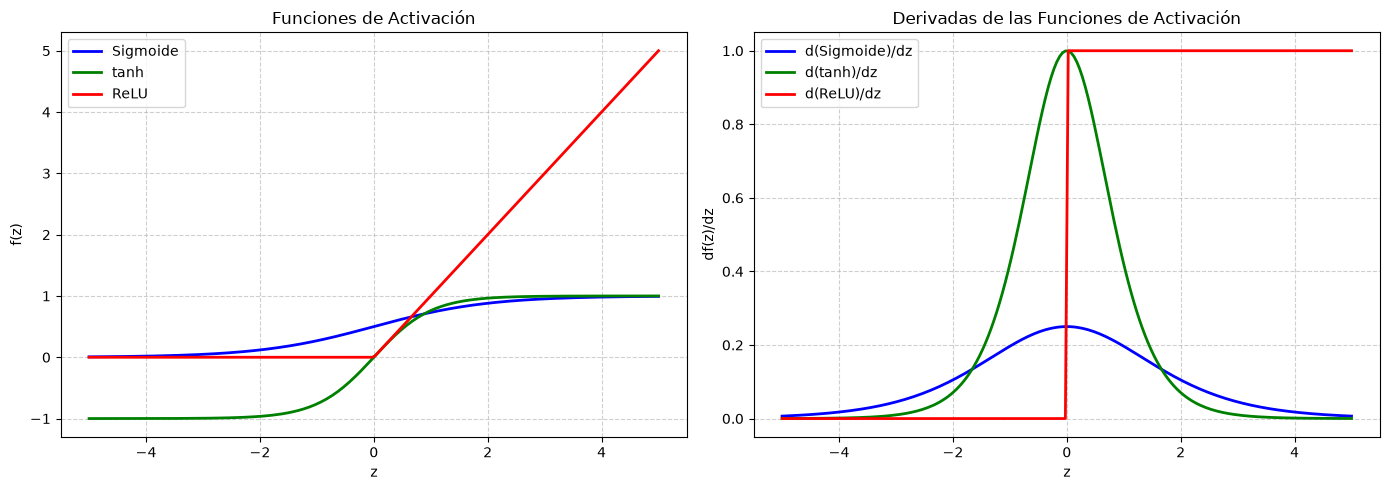

In [18]:
# funciones de activación

# definir tensor con gradiente habilitado
z = torch.linspace(-5, 5, 200, requires_grad=True)

# calcular activaciones
sig = torch.sigmoid(z)
tanh = torch.tanh(z)
relu = torch.relu(z)

# obtener derivadas exactas usando autograd
# grad_outputs=torch.ones_like(...) permite derivar elemento a elemento
grad_sig = torch.autograd.grad(outputs=sig, inputs=z, grad_outputs=torch.ones_like(sig), retain_graph=True)[0]
grad_tanh = torch.autograd.grad(outputs=tanh, inputs=z, grad_outputs=torch.ones_like(tanh), retain_graph=True)[0]
grad_relu = torch.autograd.grad(outputs=relu, inputs=z, grad_outputs=torch.ones_like(relu), retain_graph=True)[0]

# graficar funciones y sus derivadas en 2 paneles
z_np = z.detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# funciones de activación
axes[0].plot(z_np, sig.detach().numpy(), label='Sigmoide', color='blue', linewidth=2)
axes[0].plot(z_np, tanh.detach().numpy(), label='tanh', color='green', linewidth=2)
axes[0].plot(z_np, relu.detach().numpy(), label='ReLU', color='red', linewidth=2)
axes[0].set_title("Funciones de Activación")
axes[0].set_xlabel("z")
axes[0].set_ylabel("f(z)")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# derivadas de las funciones de activación
axes[1].plot(z_np, grad_sig.detach().numpy(), label="d(Sigmoide)/dz", color='blue', linewidth=2)
axes[1].plot(z_np, grad_tanh.detach().numpy(), label="d(tanh)/dz", color='green', linewidth=2)
axes[1].plot(z_np, grad_relu.detach().numpy(), label="d(ReLU)/dz", color='red', linewidth=2)
axes[1].set_title("Derivadas de las Funciones de Activación")
axes[1].set_xlabel("z")
axes[1].set_ylabel("df(z)/dz")
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()
